## Importing the Dependencies

In [40]:
# Importing the necessary libraries for data processing and model building
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

## Data Collection and Processing

In [41]:
# loading the csv data to a Pandas DataFrame
heart_data = pd.read_csv('/content/data.csv')

In [42]:
# print first 5 rows of the dataset
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [43]:
# print last 5 rows of the dataset
heart_data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [44]:
# number of rows and columns in the dataset
heart_data.shape

(303, 14)

In [45]:
# getting some info about the data
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [46]:
# checking for missing values
heart_data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [47]:
# statistical measures about the data
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [48]:
# checking the distribution of Target variable
heart_data['target'].value_counts()

,count
target,
1,165
0,138


1-->Defective Heart

2-->Healthy Heart

## Data Visualization

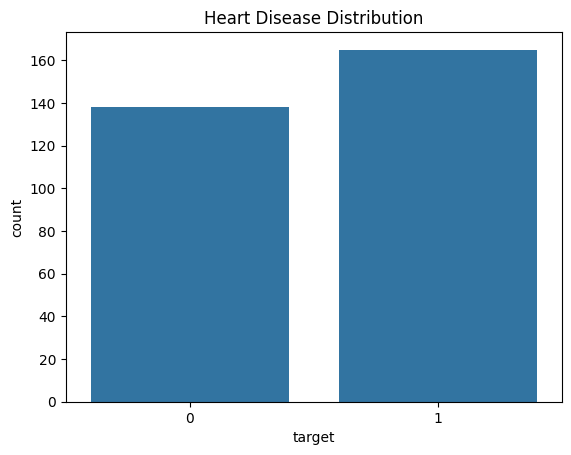

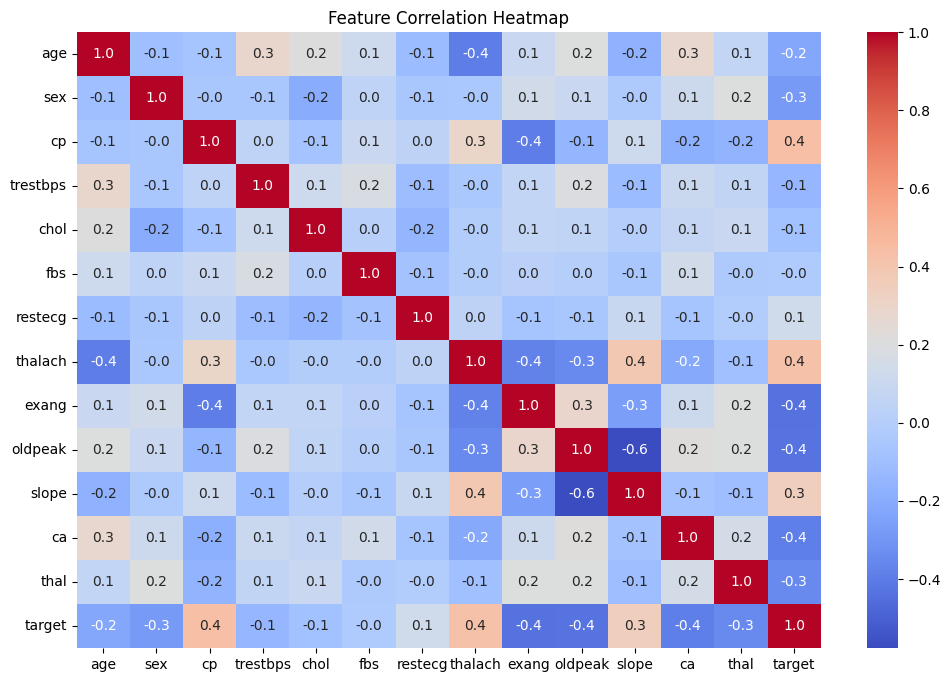

In [49]:
# Visualizing the distribution of the target variable
sns.countplot(x='target', data=heart_data)
plt.title('Heart Disease Distribution')
plt.show()

# Visualizing the correlation between all features using a heatmap
plt.figure(figsize=(12,8))
sns.heatmap(heart_data.corr(), annot=True, fmt='.1f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## Splitting the Features and Target

In [50]:
# Separating the features and target variable
X = heart_data.drop(columns='target', axis=1)
Y = heart_data['target']

print(X)
print(Y)

     age  sex  cp  trestbps  chol  ...  exang  oldpeak  slope  ca  thal
0     63    1   3       145   233  ...      0      2.3      0   0     1
1     37    1   2       130   250  ...      0      3.5      0   0     2
2     41    0   1       130   204  ...      0      1.4      2   0     2
3     56    1   1       120   236  ...      0      0.8      2   0     2
4     57    0   0       120   354  ...      1      0.6      2   0     2
..   ...  ...  ..       ...   ...  ...    ...      ...    ...  ..   ...
298   57    0   0       140   241  ...      1      0.2      1   0     3
299   45    1   3       110   264  ...      0      1.2      1   0     3
300   68    1   0       144   193  ...      0      3.4      1   2     3
301   57    1   0       130   131  ...      1      1.2      1   1     3
302   57    0   1       130   236  ...      0      0.0      1   1     2

[303 rows x 13 columns]
0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target

## Splitting the Data into Training Data & Test Data

In [51]:
# Splitting the data into training and test sets with 80-20 ratio
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

print(X.shape, X_train.shape, X_test.shape)

(303, 13) (242, 13) (61, 13)


## Feature Scaling

In [52]:
# Applying StandardScaler to normalize the feature values
scaler = StandardScaler()

# Fitting and transforming the training data
X_train = scaler.fit_transform(X_train)

# Transforming the test data using the same scaler (no fitting on test data)
X_test = scaler.transform(X_test)

## Model Training - Logistic Regression

In [53]:
# Training the Logistic Regression model on the training data
model = LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)

LogisticRegression(max_iter=1000)

## Model Evaluation

In [54]:
# Accuracy on training data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print('Accuracy on Training data:', training_data_accuracy)

# Accuracy on test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print('Accuracy on Test data:', test_data_accuracy)

# Classification report provides precision, recall and f1-score for each class
print('\nClassification Report:')
print(classification_report(Y_test, X_test_prediction))

# Confusion matrix shows the count of correct and incorrect predictions
print('Confusion Matrix:')
print(confusion_matrix(Y_test, X_test_prediction))

Accuracy on Training data: 0.8471074380165289
Accuracy on Test data: 0.7868852459016393

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.79      0.77        28
           1       0.81      0.79      0.80        33

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61

Confusion Matrix:
[[22  6]
 [ 7 26]]


## Building a Predictive System

In [55]:
# Taking sample input data for prediction
input_data = (62,0,0,140,268,0,0,160,0,3.6,0,2,2)

# Converting input data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# Reshaping the numpy array as we are predicting for only one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# Scaling the input data using the same scaler
input_data_scaled = scaler.transform(input_data_reshaped)

# Making the prediction
prediction = model.predict(input_data_scaled)
print(prediction)

if (prediction[0] == 0):
    print('The Person does not have a Heart Disease')
else:
    print('The Person has Heart Disease')

[0]
The Person does not have a Heart Disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Comparing Multiple ML Models

In [56]:
# Importing all the required models for comparison
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [57]:
# Defining all models in a dictionary for easy comparison
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000),
    'Random Forest'       : RandomForestClassifier(random_state=2),
    'SVM'                 : SVC(),
    'KNN'                 : KNeighborsClassifier(),
    'Decision Tree'       : DecisionTreeClassifier(random_state=2)
}

In [58]:
# Training each model and evaluating its accuracy on training and test data
for model_name, model in models.items():

    # Training the model
    model.fit(X_train, Y_train)

    # Accuracy on training data
    train_pred = model.predict(X_train)
    train_acc = accuracy_score(Y_train, train_pred)

    # Accuracy on test data
    test_pred = model.predict(X_test)
    test_acc = accuracy_score(Y_test, test_pred)

    print(f'{model_name}')
    print(f'  Training Accuracy : {train_acc:.4f}')
    print(f'  Test Accuracy     : {test_acc:.4f}')
    print('-' * 40)

Logistic Regression
  Training Accuracy : 0.8471
  Test Accuracy     : 0.7869
----------------------------------------
Random Forest
  Training Accuracy : 1.0000
  Test Accuracy     : 0.7705
----------------------------------------
SVM
  Training Accuracy : 0.9132
  Test Accuracy     : 0.8033
----------------------------------------
KNN
  Training Accuracy : 0.8678
  Test Accuracy     : 0.8197
----------------------------------------
Decision Tree
  Training Accuracy : 1.0000
  Test Accuracy     : 0.7705
----------------------------------------


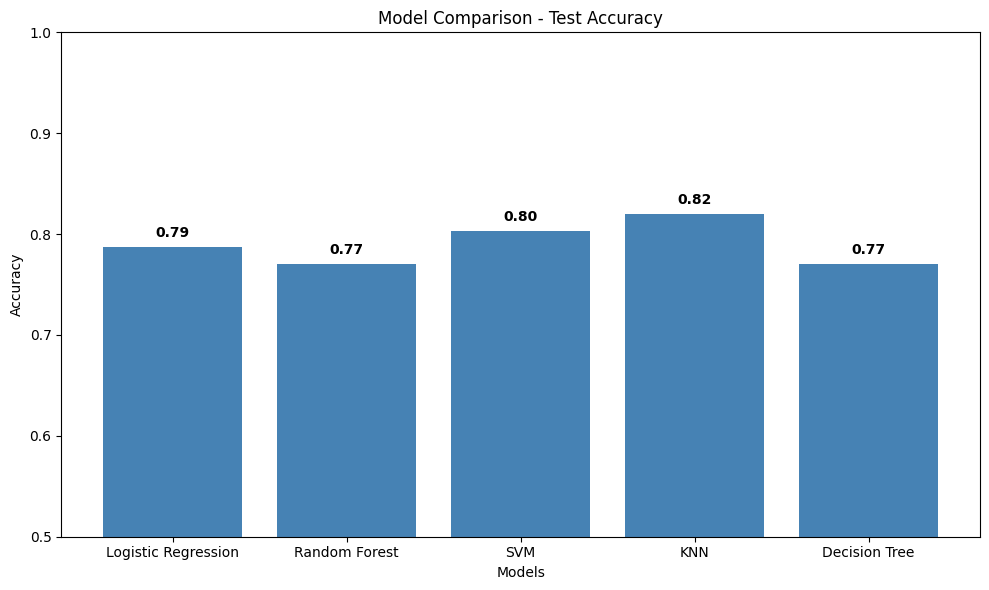

In [59]:
# Visualizing the test accuracy of all models using a bar chart
model_names = list(models.keys())
test_accuracies = []

for model_name, model in models.items():
    test_pred = model.predict(X_test)
    test_accuracies.append(accuracy_score(Y_test, test_pred))

plt.figure(figsize=(10,6))
plt.bar(model_names, test_accuracies, color='steelblue')
plt.title('Model Comparison - Test Accuracy')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)
for i, v in enumerate(test_accuracies):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [60]:
# Finding the best performing model based on test accuracy
best_model_name = model_names[test_accuracies.index(max(test_accuracies))]
best_accuracy = max(test_accuracies)
print(f'Best Performing Model : {best_model_name}')
print(f'Best Test Accuracy    : {best_accuracy:.4f}')

Best Performing Model : KNN
Best Test Accuracy    : 0.8197
